# Gradient Descent Implementation

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement gradient descent for optimization
- Tune learning rate and monitor convergence
- Apply GD to simple regression or cost minimization

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 4, lesson 01 "04. Optimization Techniques" — you ran gradient descent there on slope intuition alone, explicitly with no calculus; now you have the calculus behind the step.

**Used later in:** Course 08 (AIAT 122) — Unit 1, lesson 06 "Optimization Techniques" — `SGD` is this loop, applied in mini-batches.

---


---

## 📌 Real case: 8,192 images per step, and a warm-up that had to be invented

In 2017 a Facebook AI Research team (Goyal, Dollár, Girshick, Noordhuis, Wesolowski, Kyrola, Tulloch, Jia
and He) published **"Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour."** They trained ResNet-50
on ImageNet across **256 GPUs** with a minibatch of **8,192 images**, and finished in an hour with no loss
of accuracy against small-batch training. Two ingredients made it work, and both are about the step size in
the loop you are about to write. The first is the **linear scaling rule**: when you multiply the batch size
by *k*, multiply the learning rate by *k*. The second is a **warm-up**: they could not simply start at the
full scaled learning rate, because that broke optimisation in the early epochs, so they ramped it up from a
small value over the first five epochs.

Read that again: a team with 256 GPUs and a state-of-the-art network found that the single number
`learning_rate` decided whether the run worked at all.

**What goes wrong without this.** The experiment below is the same discovery at laboratory scale. Same
function, same starting point, same number of steps — only the learning rate changes — and the algorithm
goes from converging, to oscillating forever, to diverging to infinity.


# Gradient Descent Implementation

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Derivatives** - Understand derivatives
- ✅ **Example 2: Gradients** - Understand gradients
- ✅ **Basic understanding**: What is optimization?

**If you haven't completed these**, you might struggle with:
- Understanding gradient descent algorithm
- Understanding learning rate
- Implementing optimization

---

## 🔗 Where This Notebook Fits

**This is the THIRD example of Module 02** - puts it all together!

**Why this example THIRD?**
- **Before** you can do gradient descent, you need derivatives (Example 1) and gradients (Example 2)
- **Before** you can train ML models, you need gradient descent
- **Before** you can optimize, you need to understand the algorithm

**Builds on**: Examples 1-2 (derivatives and gradients)

**Leads to**: 
- 📓 Module 03: Optimization (advanced optimizers build on gradient descent)

---

## The Story: Understanding Before Using

Imagine you're blindfolded on a mountain and want to reach the bottom. **Before** you can do it, you need to know: feel the slope (derivative), know which way is steepest (gradient), and take small steps downhill (gradient descent). **After** understanding gradient descent, you can reach the bottom efficiently!

Same with machine learning: **Before** training models, we need to minimize loss. **After** understanding gradient descent, we can train models by iteratively moving toward the minimum!

---

## Why This Concept Matters

### Why Gradient Descent Matters in ML

**WHY** is gradient descent essential for machine learning?

1. **Model Training**:
   - **WHY**: All ML models are trained by minimizing loss
   - **HOW**: Gradient descent finds the minimum
   - **AFTER**: Enables model training

2. **Universal Algorithm**:
   - **WHY**: Works for any differentiable function
   - **HOW**: Iteratively moves toward minimum
   - **AFTER**: Foundation for all optimization

3. **Neural Networks**:
   - **WHY**: Neural networks have millions of parameters
   - **HOW**: Gradient descent optimizes all parameters
   - **AFTER**: Enables deep learning

## Learning Objectives
1. Understand gradient descent algorithm
2. Implement gradient descent in Python
3. Understand learning rate
4. Visualize gradient descent convergence
5. See how it minimizes loss functions
6. Apply to real ML scenarios

---

## Step 1: Import necessary libraries


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---

## Part 1: Setting the Scene

**BEFORE**: We understand derivatives and gradients but don't know how to use them.

**AFTER**: We'll implement gradient descent to actually minimize loss functions!

**Why this matters**: Gradient descent is how ML models learn!

**Common Student Questions:**
- **Q: What is gradient descent?**
  - Answer: Algorithm that finds minimum of a function by following the gradient (slope)
  - Like walking downhill: Take steps in direction of steepest descent
  - Used to minimize loss function in ML → find best model parameters
- **Q: Why is it called "gradient descent"?**
  - Answer: Gradient = direction of steepest increase (slope)
  - Descent = going down (toward minimum)
  - We go opposite to gradient → toward minimum → "descent"
  - Formula: `new_position = old_position - learning_rate * gradient`
- **Q: What is learning rate?**
  - Answer: Learning rate = step size (how big steps we take)
  - Too small: Slow convergence (many steps needed)
  - Too large: Might overshoot minimum (bounces around, might diverge)
  - Rule of thumb: Start with 0.01, adjust based on convergence
- **Q: Why does gradient descent work?**
  - Answer: Gradient points toward steepest increase → opposite direction = steepest decrease
  - Following gradient downhill → eventually reach minimum (or close to it)
  - Like ball rolling down hill → gravity (gradient) pulls it to bottom (minimum)
- **Q: Can gradient descent get stuck?**
  - Answer: Yes! Can get stuck in local minimum (not global minimum)
  - Problem: Gradient = 0 at minimum → stops (can't tell if local or global)
  - Solutions: Multiple random starts, momentum, adaptive learning rates
  - In practice: Local minima often good enough for ML models

## Step 2: Implementing Gradient Descent

**BEFORE**: We have a loss function but don't know how to minimize it.

**AFTER**: We'll implement gradient descent to find the minimum!

**Why gradient descent?** It's the most fundamental optimization algorithm in ML!

In [2]:
# Example 1: Basic Gradient Descent
# WHY: Find optimal parameters that minimize loss
# HOW: Iteratively move in direction opposite to gradient

def loss_function(x):
    """Simple loss function: f(x) = x²"""
    return x**2

def loss_gradient(x):
    """Gradient: f'(x) = 2x"""
    return 2 * x

def gradient_descent(x_start, learning_rate=0.1, iterations=10):
    """Perform gradient descent"""
    x = x_start
    path = [x]
    loss_path = [loss_function(x)]
    
    for i in range(iterations):
        grad = loss_gradient(x)
        x = x - learning_rate * grad  # Move opposite to gradient
        path.append(x)
        loss_path.append(loss_function(x))
    
    return path, loss_path

# Run gradient descent
x_start = 5.0
learning_rate = 0.1
path, loss_path = gradient_descent(x_start, learning_rate, iterations=10)

print("Example 1: Basic Gradient Descent")
print("=" * 60)
print(f"Minimizing f(x) = x²")
print(f"Starting at x = {x_start}, learning rate = {learning_rate}")
print(f"\nIteration process:")
for i in range(min(5, len(path)-1)):
    print(f"  Step {i+1}: x = {path[i]:.4f} → {path[i+1]:.4f}, "
          f"loss = {loss_path[i+1]:.4f}")
print(f"\n💡 WHY: We want to find x that minimizes f(x)")
print(f"💡 HOW: Move in direction opposite to gradient")
print(f"💡 AFTER: Converging to minimum at x = 0!")

Example 1: Basic Gradient Descent
Minimizing f(x) = x²
Starting at x = 5.0, learning rate = 0.1

Iteration process:
  Step 1: x = 5.0000 → 4.0000, loss = 16.0000
  Step 2: x = 4.0000 → 3.2000, loss = 10.2400
  Step 3: x = 3.2000 → 2.5600, loss = 6.5536
  Step 4: x = 2.5600 → 2.0480, loss = 4.1943
  Step 5: x = 2.0480 → 1.6384, loss = 2.6844

💡 WHY: We want to find x that minimizes f(x)
💡 HOW: Move in direction opposite to gradient
💡 AFTER: Converging to minimum at x = 0!


### 🧪 What does the learning rate actually control?

Baseline: lr = 0.1, the run above. Change one thing — the learning rate, nothing else: same f(x) = x²,
same start x = 5, same 30 steps. Measure where x ends up.

In [3]:
# Comparative experiment: five learning rates, everything else identical.
# For f(x) = x^2 the update is x <- x - lr*2x = x*(1 - 2*lr), so the behaviour is fully predictable:
# |1 - 2*lr| < 1 converges, = 1 oscillates forever, > 1 diverges. The printout is that algebra made real.

print(f"Minimising f(x) = x^2 from x = 5.0, 30 steps, only the learning rate changes.")
print()
print(f"{'learning rate':>14} {'x after 30 steps':>22} {'f(x)':>18}   verdict")
print("-" * 76)

for lr in [0.01, 0.1, 0.9, 1.0, 1.1]:
    x = 5.0
    for _ in range(30):
        x = x - lr * loss_gradient(x)
    factor = 1 - 2 * lr                     # x is multiplied by this every step
    size = abs(factor)
    if size >= 1:
        verdict = "oscillating forever, never converging" if size == 1 else "DIVERGING"
    else:
        verdict = "converging - but slowly" if size > 0.9 else "converging"
        if factor < 0:
            verdict += " (sign flips each step)"
    print(f"{lr:14.2f} {x:22.6g} {loss_function(x):18.6g}   {verdict}")

print()
print("Conclusion the numbers support: one number decides between three completely different")
print("behaviours. lr = 0.01 is safe and wastes your afternoon; lr = 0.1 lands on the minimum;")
print("lr = 0.9 reaches the same place as 0.1 but by overshooting and flipping sign each step;")
print("lr = 1.0 bounces between +5 and -5 forever with the loss never improving; lr = 1.1 walks")
print("away to infinity. There is no universally correct learning rate - the right one depends on")
print("the curvature of YOUR loss, which is why schedules and adaptive optimizers exist (Unit 3).")

Minimising f(x) = x^2 from x = 5.0, 30 steps, only the learning rate changes.

 learning rate       x after 30 steps               f(x)   verdict
----------------------------------------------------------------------------
          0.01                2.72742            7.43883   converging - but slowly
          0.10              0.0061897        3.83124e-05   converging
          0.90              0.0061897        3.83124e-05   converging (sign flips each step)
          1.00                      5                 25   oscillating forever, never converging
          1.10                1186.88        1.40869e+06   DIVERGING

Conclusion the numbers support: one number decides between three completely different
behaviours. lr = 0.01 is safe and wastes your afternoon; lr = 0.1 lands on the minimum;
lr = 0.9 reaches the same place as 0.1 but by overshooting and flipping sign each step;
lr = 1.0 bounces between +5 and -5 forever with the loss never improving; lr = 1.1 walks
away to infin

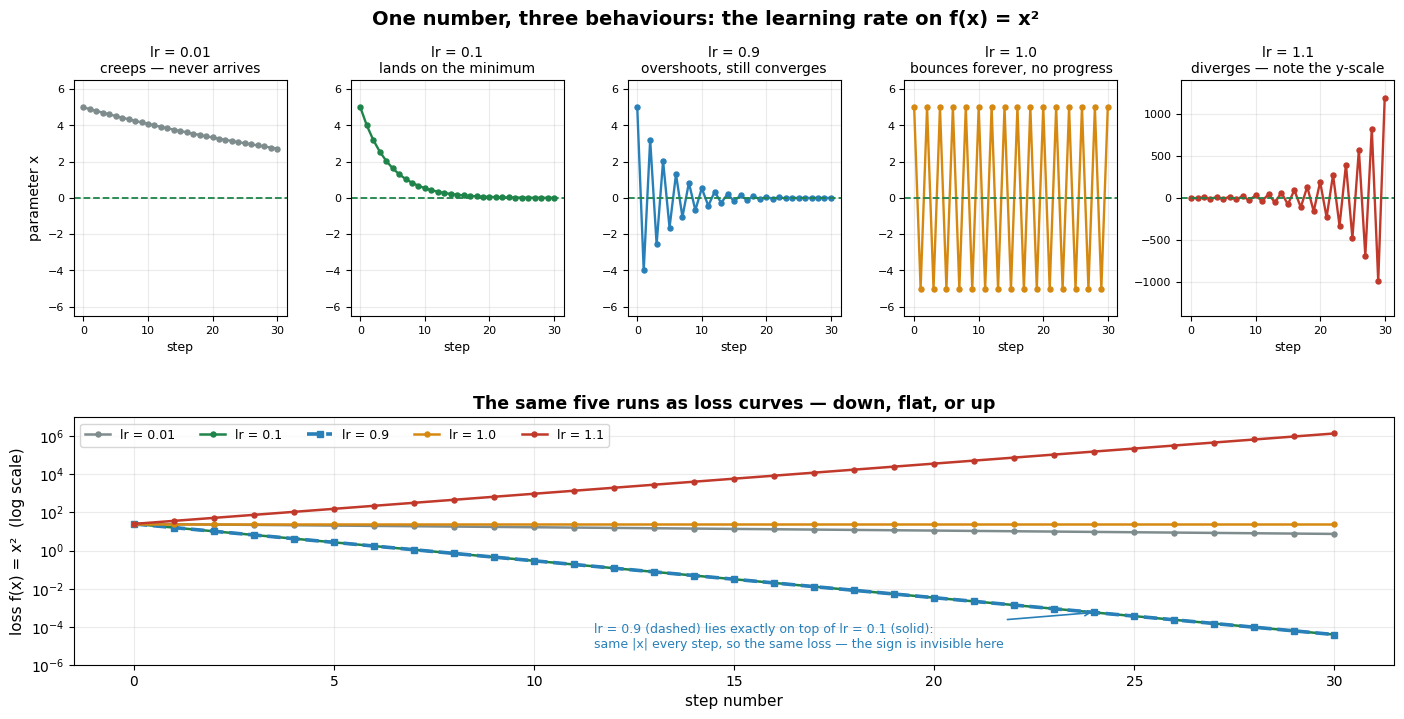

    lr   |1 - 2*lr|     x after 30 steps           loss   shape of its curve above
--------------------------------------------------------------------------------------------
  0.01         0.98              2.72742        7.43883   slow slide down, still far from 0
  0.10         0.80            0.0061897    3.83124e-05   straight line down on a log axis
  0.90         0.80            0.0061897    3.83124e-05   same loss curve as 0.1, but x flips sign every step
  1.00         1.00                    5             25   perfectly flat - no progress, ever
  1.10         1.20              1186.88    1.40869e+06   straight line UP on a log axis


In [4]:
# The five learning rates as five small panels. WHY plot it: the table above prints only
# where each run ENDED after 30 steps, so "oscillating" and "converging" look like
# similar-sized numbers. Step by step, the three behaviours have three unmistakable shapes.
# WHY one panel each rather than five lines on one axis: the runs differ by six orders of
# magnitude, so on a shared axis the interesting ones collapse into a tangle.
# Nothing changes between runs except lr — same f(x) = x², same start x = 5, same 30 steps.

lrs = [0.01, 0.1, 0.9, 1.0, 1.1]
colours = ["#7f8c8d", "#1e8449", "#2980b9", "#d68910", "#c0392b"]
verdicts = ["creeps — never arrives", "lands on the minimum",
            "overshoots, still converges", "bounces forever, no progress",
            "diverges — note the y-scale"]
steps = 30

histories = {}
for lr in lrs:
    x = 5.0
    xs = [x]
    for _ in range(steps):
        x = x - lr * loss_gradient(x)      # the identical update; only lr differs
        xs.append(x)
    histories[lr] = np.array(xs)

fig = plt.figure(figsize=(14.2, 7.4))
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1.05], hspace=0.42, wspace=0.30,
                      top=0.88, bottom=0.09, left=0.055, right=0.985)

# ---- Top row: one panel per learning rate. Same y-limits for the first four, so the
#      four pictures can be compared directly; lr = 1.1 needs its own scale.
for n, (lr, col, verdict) in enumerate(zip(lrs, colours, verdicts)):
    ax = fig.add_subplot(gs[0, n])
    ax.plot(histories[lr], "o-", color=col, ms=3.6, lw=1.7)
    ax.axhline(0, color="#1e8449", ls="--", lw=1.3)     # the target, x = 0
    if lr < 1.05:
        ax.set_ylim(-6.5, 6.5)
    else:
        ax.set_ylim(-1400, 1400)
    ax.set_title(f"lr = {lr}\n{verdict}", fontsize=10, pad=5)
    ax.set_xlabel("step", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.25)
    if n == 0:
        ax.set_ylabel("parameter x", fontsize=10)

# ---- Bottom: the loss curve you would actually watch while training, all five together.
axc = fig.add_subplot(gs[1, :])
for lr, col in zip(lrs, colours):
    style = dict(ls="--", lw=2.6, marker="s", ms=4.5) if lr == 0.9 else dict(ls="-", lw=1.8, marker="o", ms=3.6)
    axc.semilogy(loss_function(histories[lr]), color=col, label=f"lr = {lr}", **style)
axc.set_xlabel("step number", fontsize=11)
axc.set_ylabel("loss f(x) = x²  (log scale)", fontsize=11)
axc.set_title("The same five runs as loss curves — down, flat, or up",
              fontsize=12.5, fontweight="bold")
axc.set_ylim(1e-6, 1e7)
axc.legend(loc="upper left", fontsize=9, ncol=5)
axc.grid(True, which="both", alpha=0.25)
axc.annotate("lr = 0.9 (dashed) lies exactly on top of lr = 0.1 (solid):\n"
             "same |x| every step, so the same loss — the sign is invisible here",
             xy=(24, loss_function(histories[0.1][24])), xytext=(11.5, 8e-6),
             fontsize=9, color="#2980b9",
             arrowprops=dict(arrowstyle="->", color="#2980b9", lw=1.2))

fig.suptitle("One number, three behaviours: the learning rate on f(x) = x²",
             fontsize=14, fontweight="bold", y=0.975)
plt.show()

print(f"{'lr':>6} {'|1 - 2*lr|':>12} {'x after 30 steps':>20} {'loss':>14}   shape of its curve above")
print("-" * 92)
notes = {0.01: "slow slide down, still far from 0",
         0.10: "straight line down on a log axis",
         0.90: "same loss curve as 0.1, but x flips sign every step",
         1.00: "perfectly flat - no progress, ever",
         1.10: "straight line UP on a log axis"}
for lr in lrs:
    xf = histories[lr][-1]
    print(f"{lr:>6.2f} {abs(1 - 2 * lr):>12.2f} {xf:>20.6g} {loss_function(xf):>14.6g}   {notes[round(lr, 2)]}")


**Read the figure.** Five runs of the *same three lines of code*. Only `lr` changes; the function, the
start (x = 5) and the 30 steps are identical.

- **Top row — where the parameter goes.** The first four panels share the same y-axis, so they can be
  compared by eye. `lr = 0.01` (grey) slides down and is still at x = 2.73 after 30 steps: it never
  arrives. `lr = 0.1` (green) drops smoothly onto the dashed zero line and stays. `lr = 0.9` (blue)
  **crosses the zero line at every single step** — it overshoots, lands on the far side, overshoots back —
  yet the swings shrink and it converges anyway. `lr = 1.0` (orange) is a square wave between +5 and −5
  that never shrinks. `lr = 1.1` (red) needed a y-axis a **two hundred times taller** than its neighbours,
  which is the whole point: it ends at x = 1187 and is still growing.
- **Bottom panel — what you would actually see while training.** On a log axis a healthy run is a straight
  line sloping *down*. The dashed blue `lr = 0.9` curve lies **exactly on top of** the solid green
  `lr = 0.1` curve, because |1 − 2·lr| is 0.8 for both: a loss curve alone cannot tell you a run is
  thrashing across the minimum. `lr = 1.0` is perfectly **flat** — work being done, no progress. `lr = 1.1`
  is a straight line sloping *up*.
- Three completely different outcomes from changing one number. For f(x) = x² you can compute the
  threshold exactly — the update multiplies x by (1 − 2·lr), printed in the second column, and anything
  with |1 − 2·lr| ≥ 1 fails. For a real network you cannot, which is why the loss curve is watched.

## Step 3: Visualizing Gradient Descent

**BEFORE**: We implemented gradient descent but don't see how it works.

**AFTER**: We'll visualize how gradient descent converges to the minimum!

**Why visualization?** Seeing the process helps understand how it works!

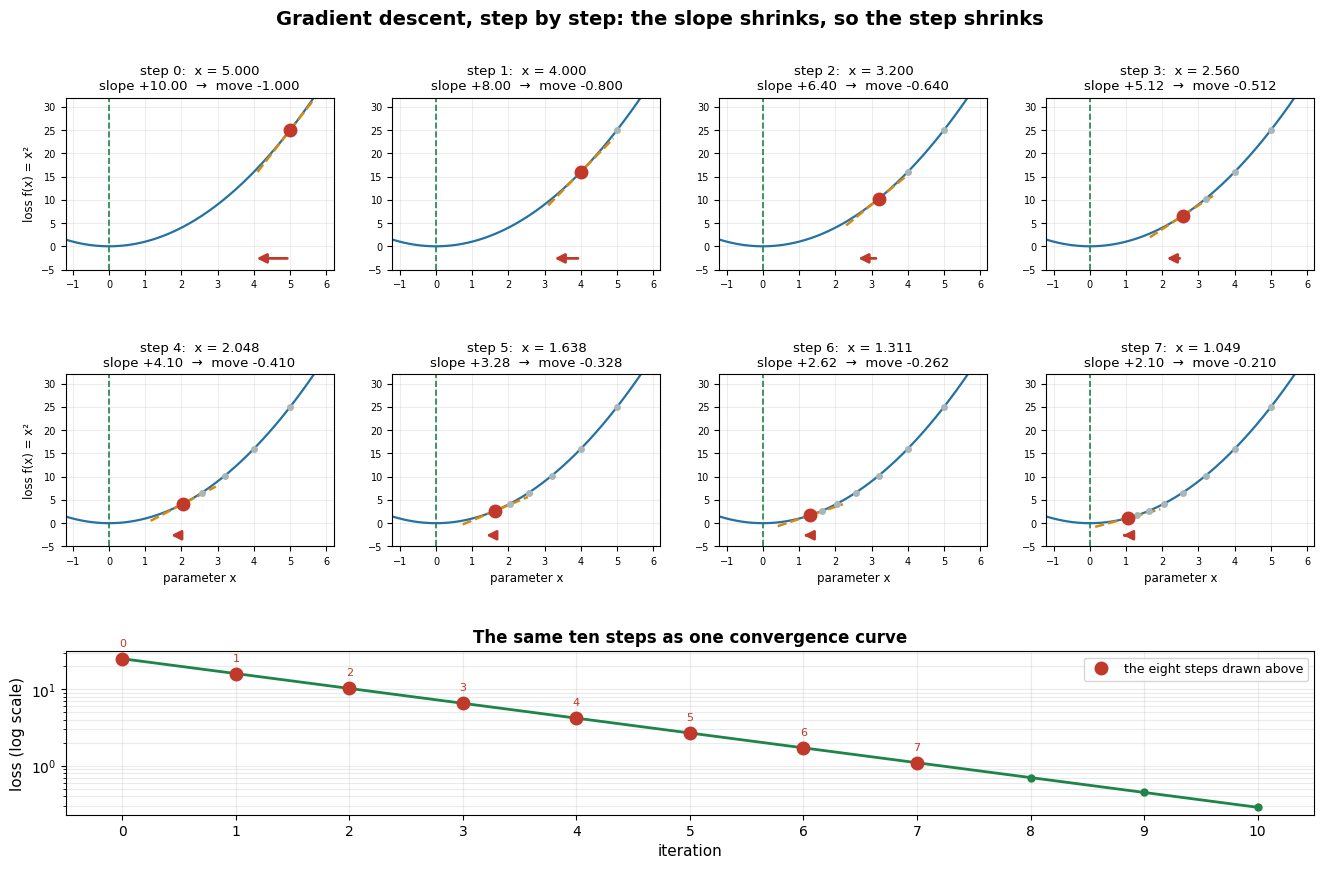

 step          x   slope f'(x)   step = -lr*slope     next x         loss
--------------------------------------------------------------------------
    0     5.0000       10.0000            -1.0000     4.0000    16.000000
    1     4.0000        8.0000            -0.8000     3.2000    10.240000
    2     3.2000        6.4000            -0.6400     2.5600     6.553600
    3     2.5600        5.1200            -0.5120     2.0480     4.194304
    4     2.0480        4.0960            -0.4096     1.6384     2.684355
    5     1.6384        3.2768            -0.3277     1.3107     1.717987
    6     1.3107        2.6214            -0.2621     1.0486     1.099512
    7     1.0486        2.0972            -0.2097     0.8389     0.703687
    8     0.8389        1.6777            -0.1678     0.6711     0.450360
    9     0.6711        1.3422            -0.1342     0.5369     0.288230

The step size is never chosen - it is -lr times the slope, so it shrinks on its own
as the curve flattens. Tha

In [5]:
# Gradient descent as a STORYBOARD: one small panel per step, so the process can be
# watched rather than summarised. WHY a frame grid instead of an animation: a grid always
# renders, prints, and survives a PDF export, and a frozen animation teaches nothing.
# Each panel shows the SAME parabola; what changes between panels is the red dot, the
# orange tangent whose slope IS the gradient, and the length of the red step arrow.

n_frames = 8
xs_grid = np.linspace(-1.2, 6.2, 200)
ys_grid = loss_function(xs_grid)

fig = plt.figure(figsize=(13.5, 8.8))
gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 0.95], hspace=0.62, wspace=0.22,
                      top=0.885, bottom=0.07, left=0.06, right=0.985)

for k in range(n_frames):
    ax = fig.add_subplot(gs[k // 4, k % 4])
    xk, xnext = path[k], path[k + 1]
    slope = loss_gradient(xk)

    ax.plot(xs_grid, ys_grid, color="#2471a3", lw=1.6)          # the loss curve
    ax.axvline(0, color="#1e8449", ls="--", lw=1.2)             # the minimum, x = 0

    # The tangent line: its steepness is the number the algorithm reacts to.
    xt = np.linspace(xk - 0.9, xk + 0.9, 2)
    ax.plot(xt, loss_function(xk) + slope * (xt - xk), "--", color="#d68910", lw=1.8)

    ax.plot(path[:k], loss_function(np.array(path[:k])), "o", color="#aab7b8", ms=4)
    ax.plot([xk], [loss_function(xk)], "o", color="#c0392b", ms=9, zorder=5)

    # The step itself, drawn along the bottom so the eight arrows can be compared.
    ax.annotate("", xy=(xnext, -2.6), xytext=(xk, -2.6),
                arrowprops=dict(arrowstyle="-|>", color="#c0392b", lw=2.0, mutation_scale=14))
    ax.set_title(f"step {k}:  x = {xk:.3f}\nslope {slope:+.2f}  →  move {xnext - xk:+.3f}",
                 fontsize=9.5, pad=6)
    ax.set_xlim(-1.2, 6.2)
    ax.set_ylim(-5, 32)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.22)
    if k % 4 == 0:
        ax.set_ylabel("loss f(x) = x²", fontsize=8.5)
    if k // 4 == 1:
        ax.set_xlabel("parameter x", fontsize=8.5)

# Bottom strip: the same run as one convergence curve, with the eight frames marked.
axc = fig.add_subplot(gs[2, :])
axc.semilogy(range(len(loss_path)), loss_path, "-", color="#1e8449", lw=2)
axc.semilogy(range(len(loss_path)), loss_path, "o", color="#1e8449", ms=5)
axc.semilogy(range(n_frames), loss_path[:n_frames], "o", color="#c0392b", ms=9,
             label="the eight steps drawn above")
for k in range(n_frames):
    axc.annotate(str(k), xy=(k, loss_path[k]), xytext=(0, 9), textcoords="offset points",
                 ha="center", fontsize=8, color="#c0392b")
axc.set_xlabel("iteration", fontsize=11)
axc.set_ylabel("loss (log scale)", fontsize=11)
axc.set_title("The same ten steps as one convergence curve", fontsize=12, fontweight="bold")
axc.set_xticks(range(len(loss_path)))
axc.legend(loc="upper right", fontsize=9)
axc.grid(True, which="both", alpha=0.25)

fig.suptitle("Gradient descent, step by step: the slope shrinks, so the step shrinks",
             fontsize=14, fontweight="bold", y=0.985)
plt.show()

print(f"{'step':>5} {'x':>10} {'slope f\'(x)':>13} {'step = -lr*slope':>18} {'next x':>10} {'loss':>12}")
print("-" * 74)
for k in range(len(path) - 1):
    g = loss_gradient(path[k])
    print(f"{k:>5} {path[k]:>10.4f} {g:>13.4f} {-learning_rate * g:>18.4f} "
          f"{path[k + 1]:>10.4f} {loss_path[k + 1]:>12.6f}")
print("\nThe step size is never chosen - it is -lr times the slope, so it shrinks on its own")
print("as the curve flattens. That is why the dots crowd together near the minimum.")


**Read the storyboard.** Eight panels, one per step, all drawn on the *same* axes and the *same*
parabola, so only the changes matter.

- The **red dot slides left** panel by panel: 5.000 → 4.000 → 3.200 → 2.560 → … Grey dots behind it are
  where it has already been.
- The **orange dashed tangent flattens**. In step 0 it is steep (slope +10.00); by step 7 it is nearly
  horizontal (slope +2.10). That tangent's steepness is the only number the algorithm ever looks at.
- The **red arrow along the bottom gets shorter** every panel — from a move of −1.000 in step 0 to −0.210
  in step 7 — because the move is exactly −lr × slope. Nobody shrinks the step; a flatter tangent does it
  automatically. Compare the first and last arrows: the last is about a fifth of the first.
- The **bottom strip** replays the same run as the loss curve you would actually watch during training.
  The eight red dots on it are the eight panels above, numbered. The curve is a straight line on a log
  axis, which is what steady convergence looks like.

The dashed green vertical in every panel is x = 0, the true minimum. The dot approaches it and never quite
lands: after 10 steps x = 0.537, not 0. Gradient descent converges *toward* a minimum; it does not solve
for it.


---

## ⚠️ Where this breaks

- **This loss is convex and one-dimensional.** `f(x) = x²` has a single minimum and constant curvature, so
  the convergence printed above proves the mechanism works — and nothing at all about a neural network's
  loss surface, which is non-convex, has many minima of different quality, and changes shape as you move.
- **The step size that works is a property of the problem, not of the algorithm.** The sweep shows the same
  code converging, oscillating and diverging under a change of one number. For f(x) = x² the threshold is
  exactly lr = 1 (because the second derivative is 2), and you can compute it. For a real network you
  cannot, which is why practitioners warm up, decay, and watch the loss curve — and why Goyal's team needed
  five epochs of ramp-up before a value they had derived from a rule was safe to use.
- **Full-batch gradient descent uses every data point per step.** On ImageNet's 1.2 million images that is
  one parameter update per complete pass over the data. Stochastic gradient descent trades an exact
  gradient for thousands of noisy updates in the same time, and the noise turns out to help escape bad
  regions. The condition that must hold before plain gradient descent is the right choice: your data fits
  in memory and a full pass is cheap.


---

## 💬 Discuss

1. At lr = 1.0 the loop never improves and never fails — it bounces between +5 and −5 forever, reporting a
   constant loss. If you saw a flat loss curve in a real training run, how would you distinguish this
   failure from "the model has converged"? What would you log to tell them apart?
2. Goyal's team derived the correct learning rate from a rule and *still* needed a five-epoch warm-up.
   What does that say about the relationship between theory and practice in ML — and how much should a
   junior engineer trust a formula from a paper?
3. You have one hour of GPU time and a model that has never been trained before. Propose a concrete
   procedure for choosing a learning rate, and say what you would give up by following it.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding gradient descent:

1. **Model Training**: Can train ML models by minimizing loss
2. **Optimization**: Understand how optimization algorithms work
3. **Neural Networks**: Ready to understand backpropagation
4. **Next Steps**: Learn advanced optimizers (Module 03) that improve on gradient descent

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand how to minimize loss functions.

**AFTER this notebook**: We can:
- ✅ Understand WHY gradient descent matters for ML
- ✅ Implement HOW gradient descent works
- ✅ See what happens AFTER (convergence to minimum)

**Next Steps**: 
- 📓 Module 03: Optimization (learn advanced optimizers)

---

## ✅ Example Complete!

## 📚 References

1. Cauchy, A.-L. (1847). *Méthode générale pour la résolution des systèmes d'équations simultanées*. Comptes Rendus de l'Académie des Sciences, 25, 536–538.
2. Robbins, H., & Monro, S. (1951). *A Stochastic Approximation Method*. The Annals of Mathematical Statistics, 22(3), 400–407.
3. Ruder, S. (2016). *An Overview of Gradient Descent Optimization Algorithms*. arXiv. <https://arxiv.org/abs/1609.04747>
4. Liu, J., Su, J., Yao, X., Jiang, Z., Lai, G., et al. (2025). *Muon is Scalable for LLM Training*. arXiv. <https://arxiv.org/abs/2502.16982> — a 2025 descent rule that orthogonalizes the update; still gradient descent with a smarter step.
5. Wen, K., Hall, D., Ma, T., & Liang, P. (2025). *Fantastic Pretraining Optimizers and Where to Find Them*. arXiv. <https://arxiv.org/abs/2509.02046> — ten optimizers tuned fairly: how much faster than plain well-tuned descent the alternatives really are.
